# Project: Urban Heat Island & Green Space Analysis

-  *Do neighborhoods with more green space stay cooler in summer?*
- *And which neighborhoods are most heat-exposed?*

In [1]:
ntatype_mapping = {
    0:"Residential",
    5:"Rikers Island",
    6:"Other Special Areas",
    7:"Cemetery",
    8:"Airport",
    9:"Park"
    }

In [2]:
! pip list

zsh:1: /Users/luciedole/Documents/Projects/NYC-Urban-Heat/geoproj/bin/pip: bad interpreter: /Users/luciedole/Documents/Projects/geoproj/bin/python: no such file or directory


Package                  Version
------------------------ -----------
affine                   2.4.0
anaconda-anon-usage      0.7.2
anaconda-auth            0.8.6
anaconda-cli-base        0.5.2
annotated-types          0.6.0
appdirs                  1.4.4
archspec                 0.2.3
attrs                    26.1.0
boltons                  25.0.0
branca                   0.8.2
brotlicffi               1.0.9.2
cachetools               7.1.4
certifi                  2025.8.3
cffi                     1.17.1
charset-normalizer       3.3.2
click                    8.4.1
cligj                    0.7.2
colorama                 0.4.6
conda                    25.7.0
conda-anaconda-telemetry 0.3.0
conda-anaconda-tos       0.2.2
conda-content-trust      0.2.0
conda-libmamba-solver    25.4.0
conda-package-handling   2.4.0
conda_package_streaming  0.12.0
contourpy                1.3.3
cryptography             45.0.5
cycler                   0.12.1
distro                   1.9.0
folium            

In [3]:
import sys
sys.path.append('..')

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import numpy as np
import xarray as xr
from rasterstats import zonal_stats, point_query
from geocube.api.core import make_geocube
import pandas as pd
import seaborn

### 2. Read the data

In [5]:
parks = '../data/raw/Parks_Properties_20260610.geojson'
neighborhoods = '../data/raw/2020_Neighborhood_Tabulation_Areas_(NTAs)_20260610.geojson'

day_in = '20230809'
day_out = '20230812'
scene_name = f'LC08_L2SP_013032_{day_in}_{day_out}_02_T1'

temperature_file = '../data/raw/' + scene_name + '/' + scene_name + '_ST_B10.TIF'
qa_file =  '../data/raw/' + scene_name + '/' + scene_name + '_QA_PIXEL.TIF'

red_file = '../data/raw/' + scene_name + '/' + scene_name + '_SR_B4.TIF'
nir_file = '../data/raw/' + scene_name + '/' + scene_name + '_SR_B5.TIF'


In [6]:
gdf_parks = gpd.read_file(parks)
gdf_neigbhorhood = gpd.read_file(neighborhoods)
ds_temperature = rioxarray.open_rasterio(temperature_file, masked=True)

qa = rioxarray.open_rasterio(qa_file, masked=False)
red_band = rioxarray.open_rasterio(red_file, masked=True) * 0.0000275 - 0.2
nir_band = rioxarray.open_rasterio(nir_file, masked=True) * 0.0000275 - 0.2

In [7]:
df_lst_ndvi = pd.read_parquet('../data/processed/20190729_20200827/lst_ndvi.parquet.gzip')
gdf_nb_temperature = gpd.read_file('../data/processed/20190729_20200827/temperature.geojson')

### 3. Prep the data

In [8]:
# sub_gdf_parks = gdf_parks[ ['acres','address','borough','class', 'typecategory','name311' , 'waterfront', 'geometry']]
# sub_gdf_nb = gdf_neigbhorhood[['borocode', 'boroname', 'ntaname', 'ntatype', 'shape_leng', 'shape_area', 'nta2020', 'geometry' ]]

In [9]:
# # sub_gdf_nb['boronumber'] = np.concat(list_boro)

# sub_gdf_nb['borocode'] = sub_gdf_nb['borocode'].astype(int)

# sub_gdf_nb["nb_id"] = sub_gdf_nb["borocode"]*100 + sub_gdf_nb.groupby("borocode").cumcount() + 1

In [10]:
# sub_gdf_nb.crs

In [11]:
# m = sub_gdf_nb.plot(
#     cmap="Blues",
# )

# sub_gdf_parks.plot(ax=m, color="green")

### 4. Satellite Data Prep

a. temperature

In [12]:
# # Bit 3 = cloud, Bit 4 = cloud shadow --> remove all clouds from temperature
# qa_int16 = qa.data.astype('int16')
# cloud_mask = (qa_int16 & 0b00001000) | (qa_int16 & 0b00010000)
# ds_temperature_masked = ds_temperature.where(cloud_mask == 0)


In [13]:
# # compute temperature (C) layer
# ds_temperature_masked.rio.crs
# ds_temperature_proj = ds_temperature_masked.rio.reproject("EPSG:4326") # same as gdfs

# # Clip the raster to the shape -> .geometry act as a mask
# lst_raw = ds_temperature_proj.rio.clip(gdf_neigbhorhood.geometry, gdf_neigbhorhood.crs)

# # Apply scale factor → convert to Celsius
# lst_celsius = lst_raw * 0.00341802 + 149.0 - 273.15
# lst_celsius.name = "temperature_celsius"


In [14]:
# lst_celsius.plot(cmap="RdYlBu_r", robust=True)
# plt.title("Land Surface Temperature - NYC area")
# plt.show()

In [15]:
# ## compute NDVI layer
# ndvi = (nir_band - red_band) / (nir_band + red_band)
# ndvi.name = "ndvi"

# ndvi = ndvi.rio.reproject("EPSG:4326")
# ndvi = ndvi.rio.clip(gdf_neigbhorhood.geometry, gdf_neigbhorhood.crs)

# ndvi.plot(cmap="RdYlGn", vmin=-1, vmax=1)
# plt.title("NDVI - NYC area")
# plt.show()

# # dense canopy reads ~0.6–0.8, mown grass ~0.3, bare infield ~0.1, pavement near 0.  -1 --> water

### 4. LST - NDVI analysis

#### Do greener blocks stay cooler?

In [16]:
# ndvi_matched = ndvi.rio.reproject_match(lst_celsius)

In [17]:
# ds = xr.merge([
#     lst_celsius.rename("lst"),
#     ndvi_matched.rename("ndvi"),
# ])

In [18]:
# df = ds.to_dataframe().reset_index().dropna(subset=["lst", "ndvi"])
# df

In [19]:

# df = df[(df["ndvi"] >0) & (df["ndvi"] <= 1)]

In [20]:
# ds_sample = df.sample(n=100000)
# ds_sample

In [22]:
df_lst_ndvi
# gdf_nb_temperature

,x,y,band,spatial_ref,lst,ndvi
1634619,-73.875874,40.817098,1,0,36.199554,0.859436
1664620,-73.869007,40.681944,1,0,46.354523,0.077174
1477933,-73.912394,40.641678,1,0,45.370117,0.208566
975338,-74.029132,40.622638,1,0,38.202545,0.290464
1957176,-73.800961,40.818035,1,0,33.379730,0.330995
...,...,...,...,...,...,...
734678,-74.085004,40.648857,1,0,35.413422,0.609488
1030456,-74.016334,40.618268,1,0,45.291504,0.316384
1527091,-73.900845,40.819595,1,0,50.316010,0.073681
416533,-74.158980,40.529310,1,0,46.993683,0.319382


In [23]:
pearson_coeff = df_lst_ndvi['lst'].corr(df_lst_ndvi['ndvi'])
slope, intercept = np.polyfit(df_lst_ndvi["ndvi"], df_lst_ndvi["lst"], 1)

print(f"Pearson r = {pearson_coeff:.3f}")
print(f"slope = {slope:.1f} °C per 1.0 NDVI  ({slope/10:.2f} °C per 0.1 NDVI)")

Pearson r = -0.668
slope = -12.1 °C per 1.0 NDVI  (-1.21 °C per 0.1 NDVI)


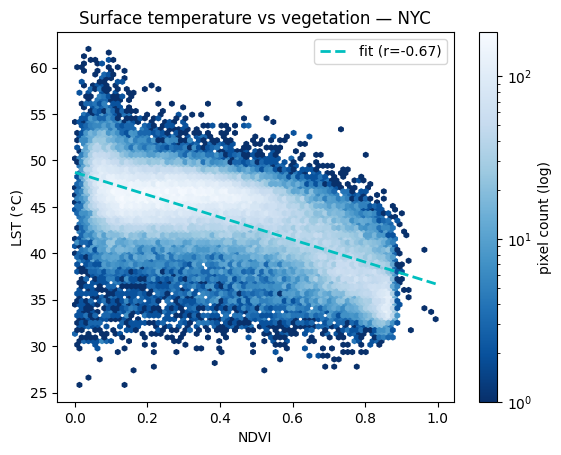

In [24]:

# scatter — but you have millions of pixels, so a raw scatter is a useless black blob.
# use hexbin (2D density) instead:
plt.hexbin(df_lst_ndvi["ndvi"], df_lst_ndvi["lst"], gridsize=80, cmap="Blues_r", mincnt=1, bins="log")
x = np.linspace(df_lst_ndvi["ndvi"].min(), df_lst_ndvi["ndvi"].max(), 100)
plt.plot(x, slope*x + intercept, "c--", lw=2, label=f"fit (r={pearson_coeff:.2f})")
plt.xlabel("NDVI"); plt.ylabel("LST (°C)")
plt.colorbar(label="pixel count (log)")
plt.legend(); plt.title("Surface temperature vs vegetation — NYC")
plt.show()


#### Answer: yes -> around 0.9 oer 0.1 ndvi. Proof (scatter + LST vs. NDVI plot)
- **slope = −9.0 °C** per NDVI unit → for every 0.1 increase in NDVI, the surface is about 0.9 °C cooler.
- **intercept ≈ 41 °C** ( NDVI = 0) → the predicted surface temperature of a fully unvegetated pixel — bare pavement/rooftop.
- r = −0.624 is the strength and direction of the linear relationship. Negative = greener is cooler. As for "good": square it — r² ≈ 0.39, meaning NDVI alone explains ~39% of the pixel-to-pixel temperature variation. For a single predictor on noisy satellite data over a whole city, that's a genuinely solid signal.

In [ ]:
# neighborhood_ds = make_geocube(
#     vector_data=sub_gdf_nb,
#     measurements=["borocode", 'nb_id'],
#     like=lst_celsius,
# )

In [ ]:
# ds_all = xr.merge([ lst_celsius.rename("lst"),
#                     ndvi_matched.rename("ndvi"),
#                     neighborhood_ds["nb_id"]
#                     ])
# df_all = ds_all.to_dataframe().reset_index().dropna(subset=["lst", "ndvi", "nb_id"])

/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_10396/2591375698.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  ds_all = xr.merge([ lst_celsius.rename("lst"),
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_10396/2591375698.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  ds_all = xr.merge([ lst_celsius.rename("lst"),
/var/folders/k8/8bd2c6

1) groupby the neighborhood id and 
2) aggregate : mean/std for LST + mean/std NDVI 
3) join those numbers back onto the neighborhood GeoDataFrame by the id 
4) plot the choropleth

In [ ]:
# df_boro_temperature = df_all.groupby('nb_id').agg(
#     x = ("x", 'mean'),
#     y = ("y", 'mean'),

#     lst_mean = ("lst", 'mean'),
#     lst_std = ("lst", 'std'),
#     lst_min = ("lst", 'min'),
#     lst_max = ("lst", 'max'),

#     ndvi_mean = ("ndvi", 'mean'),
#     ndvi_std = ("ndvi", 'std'),
#     ndvi_min = ("ndvi", 'min'),
#     ndvi_max = ("ndvi", 'max'),

# ).reset_index()

In [ ]:
# df_boro_temperature['nb_id'] = df_boro_temperature['nb_id'].astype(int)

In [ ]:
# gdf_nb_temperature = sub_gdf_nb.merge(df_boro_temperature, on='nb_id', how="left")

In [25]:
gdf_nb_tp_type0 = gdf_nb_temperature.loc[ gdf_nb_temperature.ntatype == '0']

#### The geography: heat beside green; they read as photo negatives of each other, which is your whole thesis in one glance.

<Axes: >

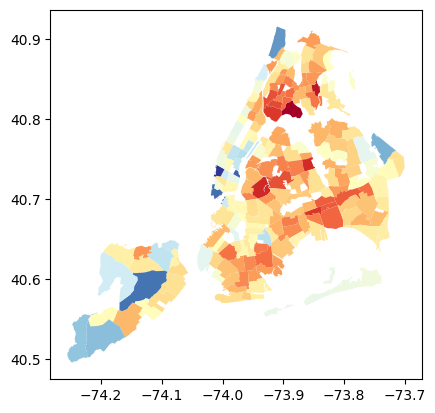

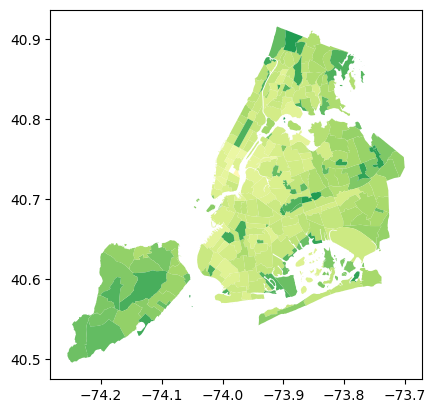

In [26]:
gdf_nb_tp_type0.plot(column='lst_mean', cmap="RdYlBu_r")
gdf_nb_temperature.plot(column='ndvi_mean', cmap="RdYlGn", vmin=-1, vmax=1)

#### Ranked Chart: hottest/coolest residential neighborhoods

In [27]:
gdf_nb_tp_type0.sort_values(by='lst_mean')[['boroname', 'ntaname', 'lst_mean', 'ndvi_mean'] ]

,boroname,ntaname,lst_mean,ndvi_mean
123,Manhattan,West Village,38.710293,0.150341
131,Manhattan,Stuyvesant Town-Peter Cooper Village,39.442139,-0.039204
118,Manhattan,Financial District-Battery Park City,39.678802,0.182215
249,Staten Island,Todt Hill-Emerson Hill-Lighthouse Hill-Manor H...,39.761471,0.677197
94,Bronx,Riverdale-Spuyten Duyvil,40.442974,0.603038
...,...,...,...,...
174,Queens,Corona,48.381313,0.204452
3,Brooklyn,East Williamsburg,48.457832,0.157458
100,Bronx,Westchester Square,48.859764,0.204347
71,Bronx,Hunts Point,49.369339,0.149870


#### Analysis of plot + chart

- basically resiential areas are less hot when they contains or are near parks with or without waterfront and near water areas

- Todt Hill has the lowest temperature with Riverdale Spuyten Duyvil because they have higher ndvi and are classified as residential. - Todt Hill and Riverdale-Spuyten Duyvil are cool via vegetation (NDVI 0.59–0.66, exactly the green=cool story).

- areas the hottest are in queens with low ndvi (+ socioeconmic aspect to come)

- But Financial District–Battery Park City is the third coolest at 35.4 °C with an NDVI of only 0.19 — barely any greenery. That's a clean counterexample inside your own data: FiDi is cool because it's wrapped in water on three sides (plus harbor breeze and tall-building street shading), not because it's green. So your instinct about "parks with or without waterfront and near water" is correct, and FiDi is the proof that water is a distinct cooling driver NDVI can't see. Worth calling out explicitly 

Pearson r = -0.255
slope = -3.0 °C per 1.0 NDVI  (-0.30 °C per 0.1 NDVI)


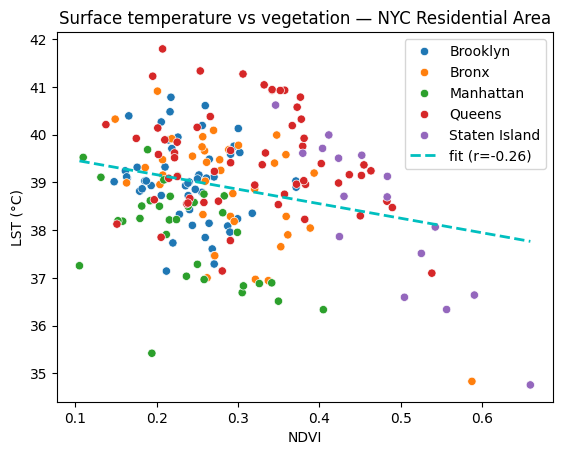

In [ ]:
pearson_coeff = gdf_nb_tp_type0['lst_mean'].corr(gdf_nb_tp_type0['ndvi_mean'])
slope, intercept = np.polyfit(gdf_nb_tp_type0["ndvi_mean"], gdf_nb_tp_type0["lst_mean"], 1)

print(f"Pearson r = {pearson_coeff:.3f}")
print(f"slope = {slope:.1f} °C per 1.0 NDVI  ({slope/10:.2f} °C per 0.1 NDVI)")

sns.scatterplot(
        x=gdf_nb_tp_type0["ndvi_mean"], 
        y=gdf_nb_tp_type0["lst_mean"], 
        hue=gdf_nb_tp_type0['boroname']
        )

x = np.linspace(gdf_nb_tp_type0["ndvi_mean"].min(), gdf_nb_tp_type0["ndvi_mean"].max(), 100)

plt.plot(x, slope*x + intercept, "c--", lw=2, label=f"fit (r={pearson_coeff:.2f})")
plt.xlabel("NDVI"); plt.ylabel("LST (°C)")
plt.legend(); plt.title("Surface temperature vs vegetation — NYC Residential Area")
plt.show()


#### LST vs. NDVI pixel mean per neighborhood for residential areas only

#### Heat inequality via lst_std

<Axes: >

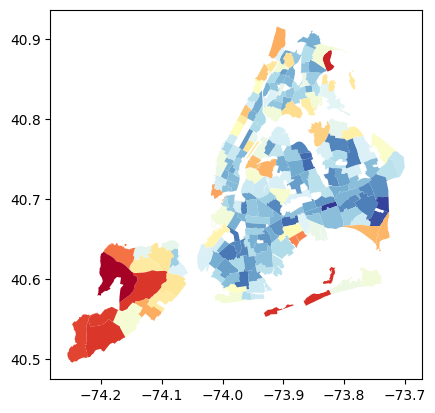

In [ ]:
gdf_nb_tp_type0.plot(column='lst_std', cmap="RdYlBu_r")

#### Synthesis: heat risk.
 neighborhoods that are simultaneously high lst_mean and low ndvi_mean are your priority zones

In [ ]:
gdf_nb_tp_type0.sort_values(by=['lst_mean', 'ndvi_mean'], ascending=[False, True])[['boroname', 'ntaname', 'lst_mean', 'lst_std','ndvi_mean',  'ndvi_std'] ]

,boroname,ntaname,lst_mean,lst_std,ndvi_mean,ndvi_std
203,Queens,South Richmond Hill,41.798740,0.641433,0.207233,0.084643
206,Queens,South Ozone Park,41.337193,1.523203,0.253554,0.124550
216,Queens,South Jamaica,41.273182,1.155108,0.306074,0.119068
215,Queens,Jamaica,41.226963,1.440251,0.195132,0.119885
220,Queens,Hollis,41.045624,1.141003,0.332059,0.115613
...,...,...,...,...,...,...
256,Staten Island,Tottenville-Charleston,36.337646,3.822053,0.556307,0.247074
142,Manhattan,Morningside Heights,36.334095,3.060809,0.404822,0.255925
118,Manhattan,Financial District-Battery Park City,35.420753,3.285960,0.194065,0.179954
94,Bronx,Riverdale-Spuyten Duyvil,34.831299,3.221105,0.587415,0.206822


Lst_std insight: 
- High-std Staten Island neighborhoods straddle forested hills/parks and developed land, so they have a big internal range — cool refuges exist. 
- The hot Queens neighborhoods have low std, meaning they're uniformly hot wall-to-wall, with nowhere to escape. That "evenly hot is worse" framing is exactly the heat-inequality story. 
- One sharpening: std alone is ambiguous (a uniformly cool place also has low std), so the signal is always std conditioned on a high mean. Low-std + high-mean = the genuinely worst case, which is precisely what you found. State it as the pair, not std by itself.